# Кандидатогенерация услуг Авито

### Как из 189 тысяч объявлений выбрать 50 с максимальной полнотой

**Масштаб:** 2 452 запроса, 189 212 объявлений, до 50 кандидатов на запрос.  
**Локальная проверка:** прирост Recall@50 повторился на двух разбиениях.

Финальная версия — гибридный retrieval: BM25/TF‑IDF, история, география,
исходная E5, дообученная query-башня E5 и CatBoostRanker.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_DIR = Path('data')
ARTIFACTS = Path('artifacts')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 90)

## 1. Что здесь нужно предсказать

Каждая строка `train` — положительное взаимодействие: пользователь ввёл запрос
и выбрал объявление. Для benchmark-запроса нужно вернуть не более 50 `item_id`.

Метрика — macro Recall@50:

$$
\text{Recall@50}=\frac{1}{|Q|}\sum_{q\in Q}
\frac{|\mathrm{top50}(q)\cap \mathrm{relevant}(q)|}
{|\mathrm{relevant}(q)|}.
$$

Главное следствие: порядок внутри пятидесяти не важен. Зато объявление, которое
не попало в пул кандидатов, поздний ранжировщик уже не спасёт. Поэтому задача
в первую очередь про **полноту поиска**, а уже потом про точную сортировку.

In [2]:
train = pd.read_parquet(DATA_DIR / 'train.parquet', columns=['search_query', 'item_id'])
queries = pd.read_parquet(DATA_DIR / 'benchmark_queries.parquet')
items = pd.read_parquet(DATA_DIR / 'benchmark_items.parquet',
                        columns=['item_id', 'item_title_raw'])

summary = pd.DataFrame({
    'объект': ['строки train', 'уникальные запросы train', 'уникальные item_id в train',
               'benchmark-запросы', 'объявления в корпусе'],
    'количество': [len(train), train.search_query.nunique(), train.item_id.nunique(),
                   len(queries), len(items)]
})
display(summary.style.format({'количество': '{:,.0f}'}).hide(axis='index'))
display(queries[['search_query', 'search_infm_params_text']].head(5)
        .rename(columns={'search_query': 'запрос', 'search_infm_params_text': 'фильтры'}))

объект,количество
строки train,"497,673"
уникальные запросы train,"74,529"
уникальные item_id в train,"344,825"
benchmark-запросы,"2,452"
объявления в корпусе,"189,212"


,запрос,фильтры
0,перевозки владикавказ тбилиси,
1,обзвон по базе,Вид услуги Деловые услуги
2,липоредукция подбородка,"Вид услуги Красота, здоровье"
3,подъемник 4 х стоечный,
4,монтаж видеодомофонов,


Короткие запросы вроде «автоподбор» или «раскопка ямы» неоднозначны. При этом
в обучении есть только клики, а честных негативов нет: отсутствие взаимодействия
не означает нерелевантность. Это делает обычную бинарную классификацию по всем
189 тысячам объявлений и слишком дорогой, и методологически сомнительной.

Я использую каскад:

> Запрос → несколько независимых источников кандидатов → объединённый пул
> примерно из 559 объявлений → CatBoostRanker → 50 `item_id`.

## 2. Из чего складывается пул кандидатов

У каждого источника своя роль:

- **BM25** хорошо ловит редкие точные слова в заголовке и описании.
- **Word TF‑IDF** покрывает слова и биграммы, **char TF‑IDF** — опечатки и разные написания.
- **E5** даёт смысловую близость запроса и объявления.
- **История взаимодействий** подсказывает тип услуги и популярные объявления для похожих запросов.
- **География** — мягкий приоритет, а не жёсткий фильтр: часть услуг удалённая,
  часть ищут в соседнем городе.

В пул никогда не добавлялись известные ответы из локальной разметки. Это важно:
иначе измеренная полнота была бы искусственной.

In [3]:
families = pd.DataFrame([
    ('Лексика', 'BM25, word/char TF-IDF', 'точные термины, формы слов, опечатки'),
    ('Семантика', 'multilingual-e5-small', 'перефразировки и близкие услуги'),
    ('Поведение', 'история похожих запросов', 'микрокатегория и клики'),
    ('География', 'локация, переходы, расстояние', 'локальные услуги без жёсткого отсечения'),
    ('Качество объявления', 'рейтинг, отзывы, цена, связь', 'финальный выбор внутри пула'),
], columns=['семейство', 'сигналы', 'зачем'])
display(families.style.hide(axis='index'))

семейство,сигналы,зачем
Лексика,"BM25, word/char TF-IDF","точные термины, формы слов, опечатки"
Семантика,multilingual-e5-small,перефразировки и близкие услуги
Поведение,история похожих запросов,микрокатегория и клики
География,"локация, переходы, расстояние",локальные услуги без жёсткого отсечения
Качество объявления,"рейтинг, отзывы, цена, связь",финальный выбор внутри пула


## 3. Как я валидировал

Случайно делить строки здесь нельзя: один и тот же запрос или контекст легко
окажется и в train, и в validation. Тогда модель увидит почти тот же клик в истории.

В локальных разбиениях я удалял из истории оцениваемые контексты, а для большой
части запросов — все строки с тем же нормализованным текстом. Отдельно смотрел
`cold`-запросы и объявления, которых модель раньше не видела в позитивной истории.

Локальная выборка всё равно не воспроизводит production-распределение идеально.
Поэтому я не опирался на один dev: финальный вариант фиксировался только после
повторения прироста на другом разбиении.

In [4]:
selection = json.loads((ARTIFACTS / 'neural_v1/candidate_union/selection.json').read_text())
verification = json.loads((ARTIFACTS / 'neural_v1/candidate_union/verification.json').read_text())

validation_table = pd.DataFrame([
    ('dev', 800, selection['baseline']['recall50'], selection['candidate']['recall50'], selection['delta']),
    ('повторная проверка', 1200, verification['baseline']['recall50'],
     verification['candidate']['recall50'], verification['delta']),
], columns=['проверка', 'запросов', 'предыдущая версия', 'финальная версия', 'разница'])
display(validation_table.style.hide(axis='index').format({
    'предыдущая версия': '{:.6f}', 'финальная версия': '{:.6f}', 'разница': '{:+.6f}'
}))
print('95% CI разницы: dev', selection['paired_ci95'],
      '| повторная проверка', verification['paired_ci95'])

проверка,запросов,предыдущая версия,финальная версия,разница
dev,800,0.945833,0.950833,+0.005000
повторная проверка,1200,0.942083,0.946806,+0.004722


95% CI разницы: dev [-0.00125, 0.0125] | повторная проверка [-0.0016666666666666668, 0.011388888888888888]


## 4. От сильного baseline к финальной версии

Сильный классический вариант уже объединял текст, исходную E5, историю и географию,
а затем ранжировал кандидатов через `PairLogit`. Его локальный Recall@50 на dev —
**0.945833**.

Дальше я не стал просто увеличивать CatBoost. Ошибки показывали, что часть нужных
объявлений вообще не попадает в исходный пул. Поэтому следующий шаг — адаптировать
семантический поиск к домену услуг.

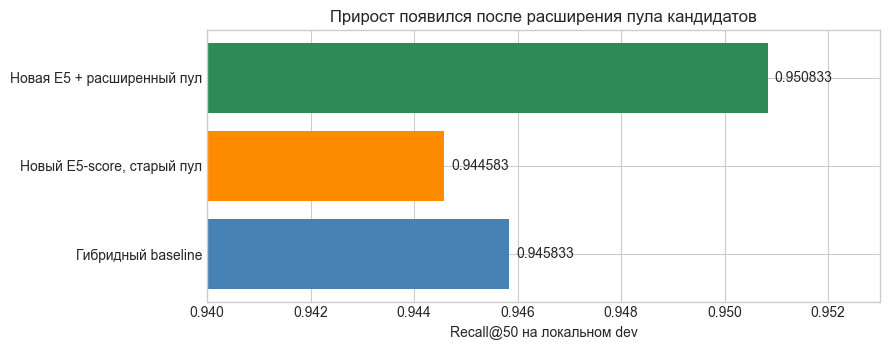

In [5]:
scores = pd.DataFrame([
    ('Гибридный baseline', 0.945833),
    ('Новый E5-score, старый пул', 0.944583),
    ('Новая E5 + расширенный пул', 0.950833),
], columns=['вариант', 'dev Recall@50'])

fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.barh(scores['вариант'], scores['dev Recall@50'],
               color=['steelblue', 'darkorange', 'seagreen'])
ax.set_xlim(0.94, 0.953)
ax.set_xlabel('Recall@50 на локальном dev')
ax.set_title('Прирост появился после расширения пула кандидатов')
ax.bar_label(bars, fmt='%.6f', padding=5)
plt.tight_layout()
plt.show()

## 5. Дообучение E5 — без лишней магии

Я оставил **document-башню замороженной**, чтобы сохранить уже посчитанные векторы
189 тысяч объявлений, и обучал только query-башню. Для известной пары
«запрос → выбранное объявление» модель приближает векторы друг к другу.
Остальные объявления батча выступают негативами, кроме других известных позитивов
того же запроса — они маскируются.

$$
L = \mathrm{CE}\left(\frac{q d^\top}{0.02}\right)
  + 0.1\,(1-\cos(q,q_{\text{old}})).
$$

Второе слагаемое не даёт query-башне слишком далеко уйти от исходной E5.
В градиентном обучении не использовались тексты локальных fit/dev/test запросов.

Пилот специально небольшой: 512 шагов × 32 пары, 14 386 разных текстов запросов.
Для ноутбука важнее идея и честная проверка, чем внушительный объём GPU-часов.

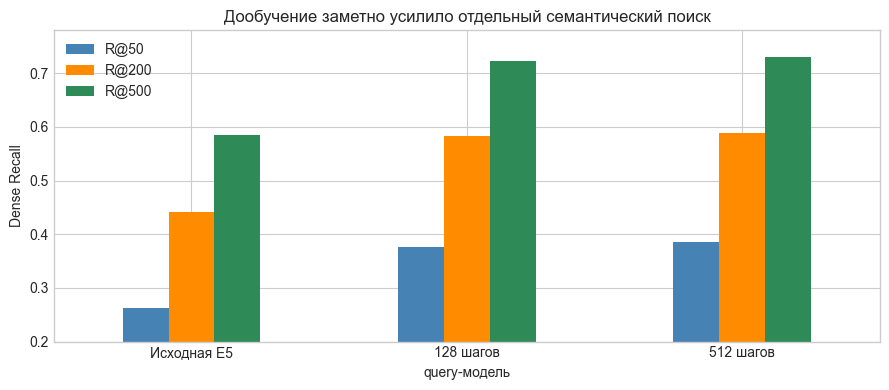

,R@50,R@200,R@500
query-модель,,,
Исходная E5,0.262708,0.442083,0.585417
128 шагов,0.375833,0.582708,0.722500
512 шагов,0.385208,0.589167,0.730000


In [6]:
dense = json.loads((ARTIFACTS / 'neural_v1/selection.json').read_text())['reports']
dense_table = pd.DataFrame([
    ('Исходная E5', dense['baseline']['dense_recall50'], dense['baseline']['dense_recall200'], dense['baseline']['dense_recall500']),
    ('128 шагов', dense['checkpoint_128']['dense_recall50'], dense['checkpoint_128']['dense_recall200'], dense['checkpoint_128']['dense_recall500']),
    ('512 шагов', dense['checkpoint_512']['dense_recall50'], dense['checkpoint_512']['dense_recall200'], dense['checkpoint_512']['dense_recall500']),
], columns=['query-модель', 'R@50', 'R@200', 'R@500']).set_index('query-модель')

ax = dense_table.plot(kind='bar', figsize=(9, 4),
                      color=['steelblue', 'darkorange', 'seagreen'])
ax.set_ylim(0.2, 0.78)
ax.set_ylabel('Dense Recall')
ax.set_title('Дообучение заметно усилило отдельный семантический поиск')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
display(dense_table.style.format('{:.6f}'))

### Важный практический вывод

Просто добавить новый cosine score к старым кандидатам оказалось недостаточно:
итоговый Recall даже слегка снизился. Прирост появился, когда новая E5 стала
**добавлять отсутствующие объявления**:

- top‑200 по новому dense-score с мягкой географией;
- top‑100 без географии;
- полный старый пул сохраняется.

Полнота пула на dev выросла с **0.97125 до 0.98125**, а ранжировщик уже решил,
какие 50 оставить. Средний объединённый пул — около 559 объявлений.

In [7]:
examples = json.loads((ARTIFACTS / 'neural_v1/candidate_union/dev_improvement_examples.json').read_text())
rows = []
for ex in examples:
    found = ', '.join(x['title'] for x in ex['new_gold_in_pool']) or 'нужный кандидат уже был в пуле, улучшилось ранжирование'
    rows.append((ex['query'], found, ex['old_recall'], ex['new_recall']))
example_table = pd.DataFrame(rows, columns=['запрос', 'что помогло', 'было', 'стало'])
display(example_table.style.hide(axis='index').format({'было': '{:.1f}', 'стало': '{:.1f}'}))

запрос,что помогло,было,стало
машина в аренду грузовая,Аренда авто Газ Sobol NN,0.0,1.0
испанский язык,"нужный кандидат уже был в пуле, улучшилось ранжирование",0.0,1.0
раскопка ямы,Разнорабочий,0.0,1.0
ютуб адсенс,"нужный кандидат уже был в пуле, улучшилось ранжирование",0.0,1.0
культиватор,"Вспашка земли, целины. Газон под ключ",0.0,1.0
удаление растяжек,Избавьтесь от целлюлита с карбокситерапией,0.0,1.0


Например, для запроса **«культиватор»** релевантное объявление называлось
«Вспашка земли, целины. Газон под ключ». Лексическое совпадение слабое, но после
адаптации смысловой поиск добавил его в пул, и объявление дошло до топ‑50.

Финальный `CatBoostRanker` обучен с `PairLogit`: 100 деревьев глубины 5.
У него 66 признаков — текстовые сходства, семантика, история, категория,
география, рейтинг/отзывы/цена и четыре оценки новой E5. Это компактная модель:
нейросеть отвечает за retrieval, бустинг — за смешивание разнородных сигналов.

## 6. Финальный ответ

`query_id` и `item_id` читаются как строки, чтобы не потерять ведущие нули.
Отдельно проверяются покрытие всех запросов, число кандидатов и дубликаты.

In [8]:
from src.validate_answer import validate

answer_path = Path('answer.csv')
report = validate(answer_path, DATA_DIR)

display(pd.DataFrame([{
    'файл': answer_path.name,
    'строк': report['rows'],
    'min кандидатов': report['min_candidates'],
    'max кандидатов': report['max_candidates'],
}]).style.hide(axis='index'))

файл,строк,min кандидатов,max кандидатов
answer.csv,2452,50,50


In [9]:
answer = pd.read_csv('answer.csv', dtype=str, keep_default_na=False)
item_title = items.set_index('item_id')['item_title_raw']
preview = []
for row in answer.head(3).itertuples(index=False):
    query = queries.loc[queries.query_id.eq(row.query_id), 'search_query'].iloc[0]
    titles = [item_title.loc[item_id] for item_id in row.answer.split()[:5]]
    preview.append({'запрос': query, 'первые 5 кандидатов': ' · '.join(titles)})
display(pd.DataFrame(preview).style.hide(axis='index'))

запрос,первые 5 кандидатов
перевозки владикавказ тбилиси,Трансфер в Грузию Гудаури Тбилиси Такси Поездки · Трансфер Владикавказ Беслан Тбилиси · Владикавказ Тбилиси трансфер такси в Грузию · Трансфер Россия Грузия Тбилиси Кутаиси Батуми · Поездки-Трансфер в Грузию Гудаури/Тбилиси/Батуми
обзвон по базе,"Обзвон базы и возврат клиентов.Лиды за 7 дней · Обзвон баз Колцентром Холодные звонки · Базы предприятий, компаний, телефонов, e-mail · Обзвон базы. Холодные звонки · Обзвон базы"
липоредукция подбородка,"Липоредукция подбородка, живота, холки · Липоредукция подбородка · Липоредукция подбородка / тела · Липоредукция удаление второго подбородка липолитик · Липосакция липоредукция подбородка холки"


## Вывод

Главным ограничением оказалась полнота кандидатного пула. Дообученная E5 помогла
находить объявления, в которых та же услуга описана другими словами. Сам по себе
новый score почти ничего не изменил; прирост появился, когда найденные объявления
стали добавляться в общий пул перед финальным ранжированием.

В результате получился понятный каскад: несколько источников отвечают за полноту,
а компактный CatBoostRanker объединяет их сигналы и выбирает итоговые 50 объявлений.

## 7. Воспроизведение

Скрипт `src/reproduce_answer.py` собирает `answer.csv` с нуля из трёх
исходных parquet-файлов. При первом запуске скачивается зафиксированная
версия E5 из HuggingFace, кодируются все тексты, строится лексический индекс,
загружается дообученный адаптер и ранжировщик. В конце проверяется SHA256.

```bash
cd src
python reproduce_answer.py
```

На CPU это занимает около часа (основное время — кодирование 189k объявлений).
Результаты кешируются в `artifacts/reproduce/`, повторный запуск — около 10 минут.

In [ ]:
import hashlib

expected = 'db6826cb284becd9a00de2c29452bdff30be42afad9744877352a0a374cdd6ce'
actual = hashlib.sha256(Path('answer.csv').read_bytes()).hexdigest()

print(f'SHA256:   {actual}')
print(f'Ожидали:  {expected}')
print('Совпадает!' if actual == expected else 'Не совпадает — проверьте версии библиотек.')